In [ ]:
## Setup and Data Preparation Importing Libraries

In [75]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Check setup
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device   :", device)

PyTorch version: 2.7.0
CUDA available : False
Using device   : cpu


In [ ]:
## Loading the Dataset

In [76]:
df = pd.read_csv('twitter_training.csv',
                 header=None,
                 names=['id', 'entity', 'sentiment', 'text'])

print("Shape:", df.shape)
df.head()

Shape: (74682, 4)


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


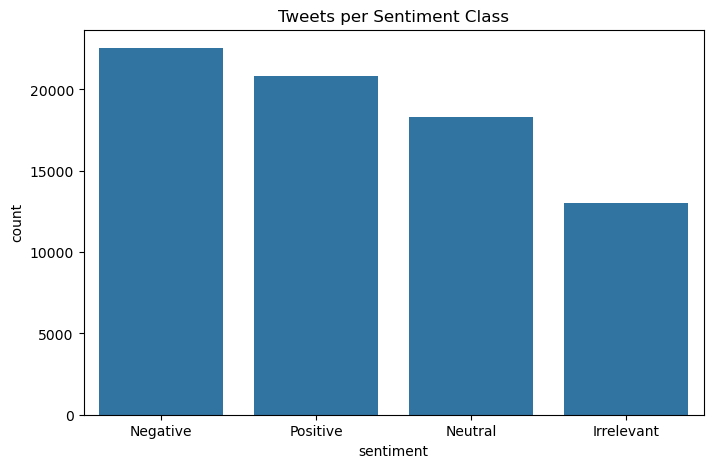

In [77]:
print(df['sentiment'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index)
plt.title('Tweets per Sentiment Class')
plt.show()

In [ ]:
##Preprocessing Cleaning the Text

In [78]:
# Drop rows with missing text
df = df.dropna(subset=['text']).reset_index(drop=True)
# remove links,@mentions,punctuation and numbers,extra spaces,keep hashtag word, drop the #,
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)     
    text = re.sub(r'@\w+', '', text)              
    text = re.sub(r'#', '', text)                   
    text = re.sub(r'[^a-z\s]', ' ', text)           
    text = re.sub(r'\s+', ' ', text).strip()       
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


In [79]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [ ]:
## Tokenization and Padding

In [80]:
import numpy as np
from collections import Counter

MAX_WORDS = 20000
MAX_LEN = 50

# Build vocabulary from the cleaned tweets
all_words = []
for text in df['clean_text']:
    all_words.extend(text.split())

word_counts = Counter(all_words)
most_common = word_counts.most_common(MAX_WORDS - 2)   # reserve room for PAD and OOV

word_index = {'<PAD>': 0, '<OOV>': 1}
for i, (word, _) in enumerate(most_common, start=2):
    word_index[word] = i

# Convert tweets to fixed-length integer sequences
def text_to_sequence(text, word_index, max_len):
    tokens = text.split()
    seq = [word_index.get(w, word_index['<OOV>']) for w in tokens]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X = np.array([text_to_sequence(t, word_index, MAX_LEN) for t in df['clean_text']])
y = df['label'].values

print("Vocabulary size:", len(word_index))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample sequence (first 20 tokens):", X[0][:20])

Vocabulary size: 20000
X shape: (73996, 50)
y shape: (73996,)

Sample sequence (first 20 tokens): [ 297  169   14  154    5    3   55 1662   13   27    0    0    0    0
    0    0    0    0    0    0]


In [ ]:
## Train/Test Split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (59196, 50)
Test size : (14800, 50)


In [ ]:
## Building the RNN Model

In [82]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

NUM_CLASSES   = len(le.classes_)
EMBEDDING_DIM = 64
HIDDEN_DIM    = 64
VOCAB_SIZE    = MAX_WORDS

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            nonlinearity='tanh',
            batch_first=True
        )
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.embedding(x)             # (batch, seq, embed_dim)
        _, hidden = self.rnn(x)           # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)        # (batch, hidden_dim)
        x = self.dropout1(hidden)
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

model = SentimentRNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu
SentimentRNN(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (rnn): RNN(64, 64, batch_first=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
)

Total parameters: 1,290,532


In [67]:
## Training the model

In [83]:
from torch.utils.data import DataLoader, TensorDataset

# Convert NumPy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Carve out a 10% validation slice from training data
val_size   = int(0.1 * len(X_train_t))
train_size = len(X_train_t) - val_size

train_ds = TensorDataset(X_train_t[:train_size], y_train_t[:train_size])
val_ds   = TensorDataset(X_train_t[train_size:], y_train_t[train_size:])
test_ds  = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 417
Val batches  : 47
Test batches : 116


In [84]:
EPOCHS   = 10
PATIENCE = 2

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ---- Train ----
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_fn(outputs, yb)
        loss.backward()
        optimizer.step()

        train_loss   += loss.item() * xb.size(0)
        train_correct += (outputs.argmax(1) == yb).sum().item()
        train_total   += xb.size(0)

    train_loss /= train_total
    train_acc  = train_correct / train_total

    # ---- Validate ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            val_loss    += loss.item() * xb.size(0)
            val_correct += (outputs.argmax(1) == yb).sum().item()
            val_total   += xb.size(0)

    val_loss /= val_total
    val_acc  = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # ---- Early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

# Restore best weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Restored best model based on validation loss.")

Epoch  1/10 | train_loss=1.3685 train_acc=0.2946 | val_loss=1.3634 val_acc=0.3053
Epoch  2/10 | train_loss=1.3662 train_acc=0.2995 | val_loss=1.3616 val_acc=0.3068
Epoch  3/10 | train_loss=1.3636 train_acc=0.3021 | val_loss=1.3607 val_acc=0.3055
Epoch  4/10 | train_loss=1.3601 train_acc=0.3022 | val_loss=1.3600 val_acc=0.3058
Epoch  5/10 | train_loss=1.3551 train_acc=0.3076 | val_loss=1.3596 val_acc=0.3050
Epoch  6/10 | train_loss=1.3488 train_acc=0.3129 | val_loss=1.3589 val_acc=0.3056
Epoch  7/10 | train_loss=1.3455 train_acc=0.3136 | val_loss=1.3589 val_acc=0.3093
Epoch  8/10 | train_loss=1.3393 train_acc=0.3158 | val_loss=1.3563 val_acc=0.3137
Epoch  9/10 | train_loss=1.3331 train_acc=0.3212 | val_loss=1.3567 val_acc=0.3115
Epoch 10/10 | train_loss=1.3225 train_acc=0.3330 | val_loss=1.3539 val_acc=0.3124
Restored best model based on validation loss.


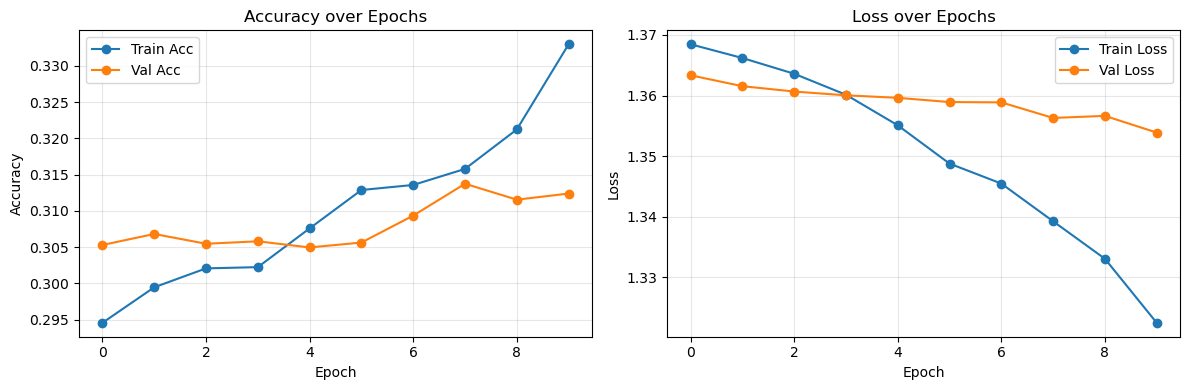

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Test Accuracy: 0.3109

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.42      0.03      0.06      2575
    Negative       0.52      0.13      0.21      4472
     Neutral       0.34      0.05      0.09      3622
    Positive       0.29      0.91      0.44      4131

    accuracy                           0.31     14800
   macro avg       0.39      0.28      0.20     14800
weighted avg       0.40      0.31      0.22     14800

